[*********************100%***********************]  2 of 2 completed


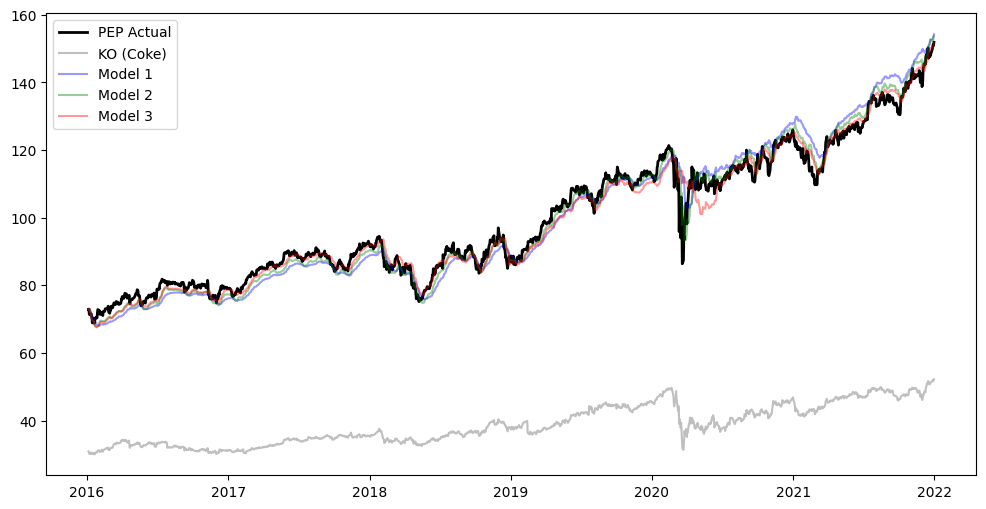

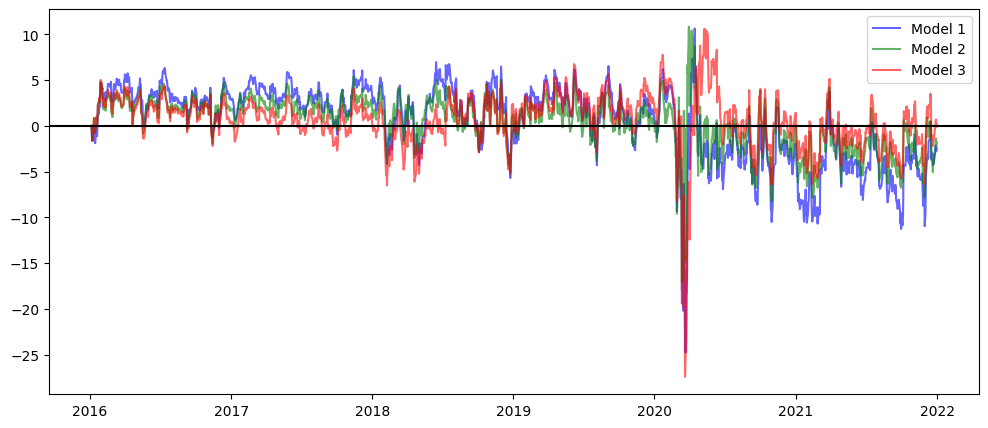

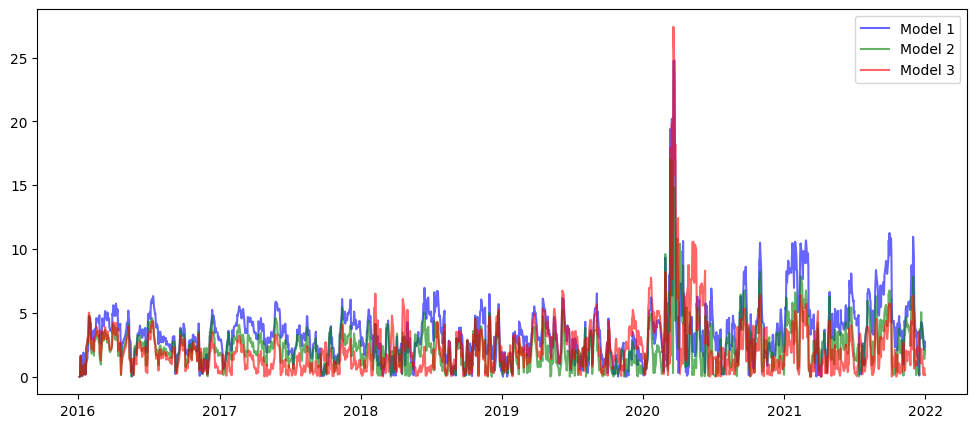

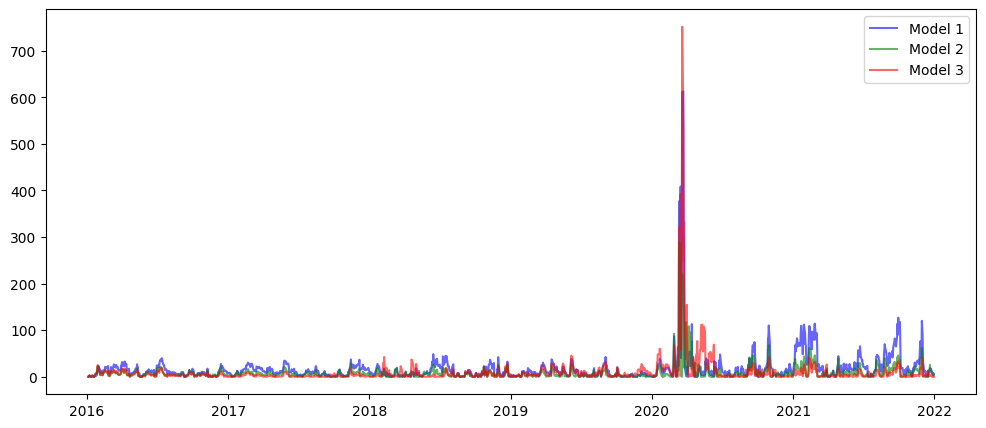

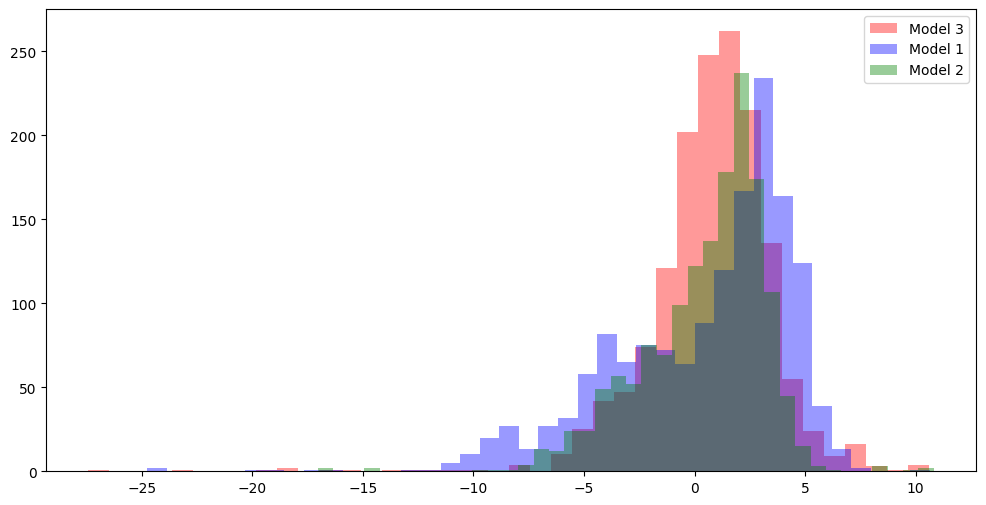

In [2]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

tickers = ["KO", "PEP"]
data = yf.download(tickers, start="2016-01-01", end="2022-01-01")["Close"].dropna()

dates = data.index 

returns = data.pct_change().dropna()

y = returns["PEP"].values
x = returns["KO"].values

dates_ret = returns.index  # aligned with returns

pep_prices = data["PEP"].values[1:]
ko_prices  = data["KO"].values[1:]


def model1(x, y):
    n = len(y)
    x_hat = np.zeros((2, n))
    P = np.eye(2)

    A = np.eye(2)
    Q = 1e-5 * np.eye(2)
    R = 1e-3

    y_pred = np.zeros(n)

    for t in range(1, n):

        H = np.array([[1, x[t-1]]])

        x_pred = A @ x_hat[:, t-1]
        P_pred = A @ P @ A.T + Q

        pred = (H @ x_pred).item()
        y_pred[t] = pred

        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)

        err = y[t] - pred
        x_hat[:, t] = x_pred + K.flatten() * err
        P = (np.eye(2) - K @ H) @ P_pred

    y_pred[0] = y_pred[1]
    return y_pred


def model2(x, y):
    n = len(y)
    x_hat = np.zeros((3, n))
    P = np.eye(3)

    A = np.eye(3)
    Q = 1e-3 * np.eye(3)
    R = 1e-2

    y_pred = np.zeros(n)

    for t in range(2, n):

        H = np.array([[1, x[t-1], y[t-1]]])

        x_pred = A @ x_hat[:, t-1]
        P_pred = A @ P @ A.T + Q

        y_pred[t] = (H @ x_pred).item()

        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)

        err = y[t] - y_pred[t]
        x_hat[:, t] = x_pred + K.flatten() * err
        P = (np.eye(3) - K @ H) @ P_pred

    return y_pred


def model3(x, y):
    n = len(y)
    x_hat = np.zeros((3, n))
    P = np.eye(3)

    A = np.eye(3)
    R = 1e-2
    lam = 0.98

    y_pred = np.zeros(n)

    for t in range(2, n):

        H = np.array([[1, x[t-1], y[t-1]]])

        vol = np.var(y[max(0, t-20):t])
        Q = (1e-4 + 5 * vol) * np.eye(3)

        x_pred = A @ x_hat[:, t-1]
        P_pred = (A @ P @ A.T + Q) / lam

        y_pred[t] = (H @ x_pred).item()

        err = y[t] - y_pred[t]

        if abs(err) > 3 * np.std(y):
            x_hat[:, t] = 0
            P = np.eye(3) * 10
            continue

        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)

        x_hat[:, t] = x_pred + K.flatten() * err
        P = (np.eye(3) - K @ H) @ P_pred

    return y_pred


p1 = model1(x, y)
p2 = model2(x, y)
p3 = model3(x, y)


def rebuild(pred_returns, base):
    out = np.zeros_like(base)
    out[0] = base[0]
    for t in range(1, len(out)):
        out[t] = out[t-1] * (1 + pred_returns[t-1])
    return out

p1p = rebuild(p1, pep_prices)
p2p = rebuild(p2, pep_prices)
p3p = rebuild(p3, pep_prices)


colors = {
    "m1": "blue",
    "m2": "green",
    "m3": "red",
}

plt.figure(figsize=(12,6))

plt.plot(dates_ret,pep_prices, label="PEP Actual", linewidth=2, color="black")
plt.plot(dates_ret,ko_prices, label="KO (Coke)", alpha=0.5, color="gray")

plt.plot(dates_ret, p1p, label="Model 1", alpha=0.4,color=colors["m1"])
plt.plot(dates_ret, p2p, label="Model 2", alpha=0.4,color=colors["m2"])
plt.plot(dates_ret, p3p, label="Model 3", alpha=0.4,color=colors["m3"])

#plt.title("Kalman Models vs Actual Prices")
plt.legend()
plt.show()

def errors(pred):
    e = pep_prices - pred
    return e, np.abs(e), e**2

e1, ae1, se1 = errors(p1p)
e2, ae2, se2 = errors(p2p)
e3, ae3, se3 = errors(p3p)


plt.figure(figsize=(12,5))

plt.plot(dates_ret, e1, label="Model 1", alpha=0.6, color="blue")
plt.plot(dates_ret, e2, label="Model 2", alpha=0.6, color="green")
plt.plot(dates_ret, e3, label="Model 3", alpha=0.6, color="red")

plt.axhline(0, color="black")
#plt.title("Residual Errors Over Time")
plt.legend()
plt.show()


plt.figure(figsize=(12,5))

plt.plot(dates_ret, ae1, alpha=0.6, label="Model 1", color="blue")
plt.plot(dates_ret, ae2, alpha=0.6, label="Model 2", color="green")
plt.plot(dates_ret, ae3, alpha=0.6, label="Model 3", color="red")

#plt.title("Absolute Errors Over Time")
plt.legend()
plt.show()

plt.figure(figsize=(12,5))

plt.plot(dates_ret, se1, alpha=0.6, label="Model 1", color="blue")
plt.plot(dates_ret, se2, alpha=0.6, label="Model 2", color="green")
plt.plot(dates_ret, se3, alpha=0.6, label="Model 3", color="red")

#plt.title("Squared Errors Over Time")
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.hist(e3, bins=40, alpha=0.4, label="Model 3", color="red")

plt.hist(e1, bins=40, alpha=0.4, label="Model 1", color="blue")
plt.hist(e2, bins=40, alpha=0.4, label="Model 2", color="green")


#plt.title("Error Distributions")
plt.legend()
plt.show()